### ✅ Preprocessing Steps (Following *A Comprehensive Pipeline for Aortic Segmentation and Shape Analysis*)

This project applies the same preprocessing described in the paper  
**“A Comprehensive Pipeline for Aortic Segmentation and Shape Analysis”**  
(https://arxiv.org/pdf/2509.09718) [1](https://arxiv.org/pdf/2509.09718)

The preprocessing steps include:

1. **Intensity Clipping**  
   - Clip voxel intensities to the **0.5th and 99.5th percentiles** to remove outliers.  
     This stabilizes the dynamic range and reduces the effect of extreme noise values.  
     [1](https://arxiv.org/pdf/2509.09718)

2. **Intensity Rescaling**  
   - Rescale intensity values to a **0–255** range while **preserving zero values**,  
     ensuring consistent contrast representation across images and compatibility  
     with the training pipelines.  
     [1](https://arxiv.org/pdf/2509.09718)

3. **Orientation Standardization**  
   - All MRI volumes are reoriented to the **RAS (Right–Anterior–Superior)**  
     coordinate system for compatibility with **nnU‑Net** training.  
     [1](https://arxiv.org/pdf/2509.09718)

These steps ensure standardized data representation, stable model training, and  
alignment with the preprocessing strategy used in the original publication.

In [17]:

import nibabel as nib
import numpy as np
from nibabel.orientations import (
    axcodes2ornt,
    ornt_transform,
    apply_orientation
)


In [2]:
def preprocess_mri_for_nnunet(
    nifti_path,
    output_path,
    lower_percentile=0.5,
    upper_percentile=99.5
):
    """
    Preprocess MRI volume following the pipeline described in
    'A Comprehensive Pipeline for Aortic Segmentation and Shape Analysis'.

    Steps:
    1. Intensity clipping (0.5–99.5 percentile)
    2. Intensity rescaling to 0–255 (preserving zeros)
    3. Reorientation to RAS for nnU-Net
    """

    # ------------------------------------------------------------------
    # Load NIfTI
    # ------------------------------------------------------------------
    img = nib.load(nifti_path)
    data = img.get_fdata()
    affine = img.affine

    # ------------------------------------------------------------------
    # 1. Intensity clipping (exclude zero background)
    # ------------------------------------------------------------------
    nonzero = data[data > 0]
    if nonzero.size > 0:
        p_low = np.percentile(nonzero, lower_percentile)
        p_high = np.percentile(nonzero, upper_percentile)
        data = np.clip(data, p_low, p_high)

    # ------------------------------------------------------------------
    # 2. Rescale intensities to 0–255 (preserve zero values)
    # ------------------------------------------------------------------
    nonzero = data[data > 0]
    if nonzero.size > 0:
        min_val = nonzero.min()
        max_val = nonzero.max()
        data[data > 0] = 255.0 * (data[data > 0] - min_val) / (max_val - min_val)

    data = data.astype(np.float32)

    # ------------------------------------------------------------------
    # 3. Reorient volume to RAS (Right–Anterior–Superior)
    # ------------------------------------------------------------------
    current_ornt = nib.orientations.io_orientation(affine)
    target_ornt = axcodes2ornt(("R", "A", "S"))

    transform = ornt_transform(current_ornt, target_ornt)
    data = apply_orientation(data, transform)

    new_affine = img.affine.copy()
    new_affine = nib.orientations.inv_ornt_aff(transform, data.shape)

    # ------------------------------------------------------------------
    # Save preprocessed NIfTI
    # ------------------------------------------------------------------
    out_img = nib.Nifti1Image(data, new_affine)
    nib.save(out_img, output_path)

    print(f"✅ Preprocessed volume saved to:\n{output_path}")

### the following cell is no linger needed to be run as all files have been preprocessed

In [18]:
import os

# input_dir = r"D:\projects\4D-flow-MRI-aortic-segmentation-\data\ao_imgs"
# output_dir = r"D:\projects\4D-flow-MRI-aortic-segmentation-\data\ao_imgs_preprocessed"

# os.makedirs(output_dir, exist_ok=True)

# for filename in sorted(os.listdir(input_dir)):
#     if filename.endswith(".nii.gz"):
#         input_path = os.path.join(input_dir, filename)
#         output_path = os.path.join(output_dir, filename)
#         preprocess_mri_for_nnunet(input_path, output_path)

# print(f"\n✅ All files processed and saved to:\n{output_dir}")

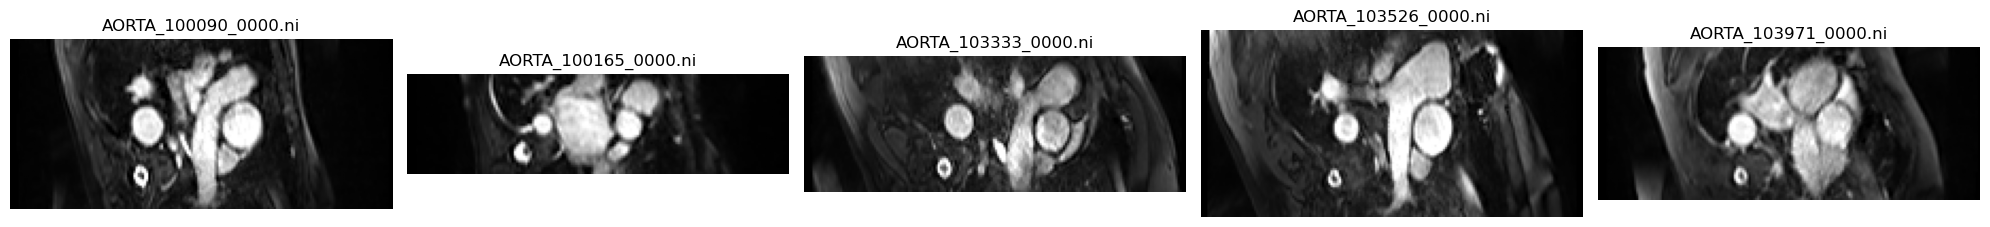

In [11]:
import matplotlib.pyplot as plt
import os

def visualize_nifti_slices(nifti_dir, n_images=5, slice_idx=None):
    """Visualize slices from multiple NIfTI files."""
    files = sorted([f for f in os.listdir(nifti_dir) if f.endswith('.nii.gz')])[:n_images]
    
    fig, axes = plt.subplots(1, n_images, figsize=(4*n_images, 4))
    if n_images == 1:
        axes = [axes]
    
    for i, filename in enumerate(files):
        img = nib.load(os.path.join(nifti_dir, filename))
        data = img.get_fdata()
        
        if slice_idx is None:
            slice_idx = data.shape[2] // 2
        
        axes[i].imshow(data[:, :, slice_idx], cmap='gray')
        axes[i].set_title(filename[:20])
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

output_dir = r"D:\projects\4D-flow-MRI-aortic-segmentation-\data\ao_imgs_preprocessed"
visualize_nifti_slices(output_dir, n_images=5)

C:\Users\Hala\AppData\Local\Temp\ipykernel_17592\1932753449.py:31: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


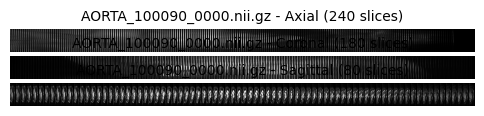

In [12]:
output_dir = r"D:\projects\4D-flow-MRI-aortic-segmentation-\data\ao_imgs_preprocessed"

def visualize_all_slices(nifti_dir, filename=None, q=None):
    """Visualize slices (axial, coronal, sagittal) for one MRI volume."""
    files = sorted([f for f in os.listdir(nifti_dir) if f.endswith('.nii.gz')])
    
    if filename is None:
        filename = files[0]
    
    img = nib.load(os.path.join(nifti_dir, filename))
    data = img.get_fdata()
    
    x, y, z = data.shape
    
    if q is not None:
        z = min(q, z)
        y = min(q, y)
        x = min(q, x)
    
    fig, axes = plt.subplots(3, 1, figsize=(6, 3*x/z if z > 0 else 6))
    
    for i, (view, slices) in enumerate([
        ('Axial', [data[:, :, j] for j in range(z)]),
        ('Coronal', [data[:, i, :] for i in range(y)]),
        ('Sagittal', [data[i, :, :] for i in range(x)])
    ]):
        axes[i].imshow(np.hstack(slices), cmap='gray', aspect='auto')
        axes[i].set_title(f'{filename} - {view} ({len(slices)} slices)', fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_all_slices(output_dir)

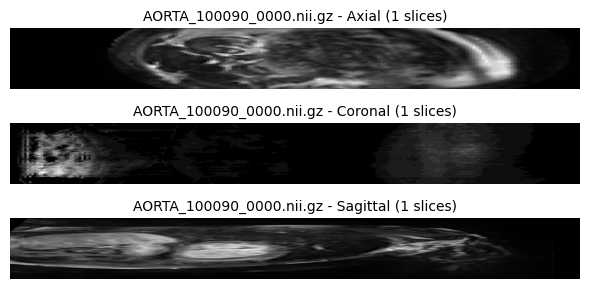

In [13]:
visualize_all_slices(output_dir,q=1)

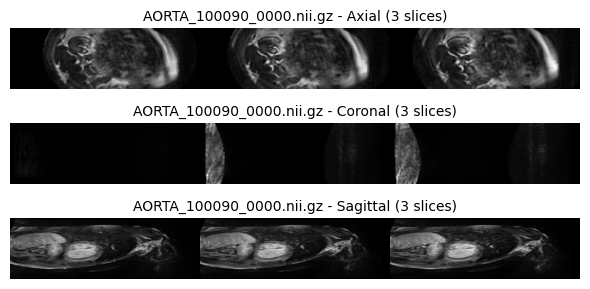

In [14]:
visualize_all_slices(output_dir,q=3)

In [15]:
import os
from collections import Counter

preprocessed_dir = r"D:\projects\4D-flow-MRI-aortic-segmentation-\data\ao_imgs_preprocessed"

files = sorted([f for f in os.listdir(preprocessed_dir) if f.endswith('.nii.gz')])

slice_counts = []
for filename in files:
    img = nib.load(os.path.join(preprocessed_dir, filename))
    data = img.get_fdata()
    slice_counts.append(data.shape[2])
    print(f"{filename}: {data.shape[2]} slices")

count = Counter(slice_counts)
print(f"\nSlice count distribution: {count}")
print(f"All files have same number of slices: {len(count) == 1}")

AORTA_100090_0000.nii.gz: 240 slices
AORTA_100165_0000.nii.gz: 224 slices
AORTA_103333_0000.nii.gz: 240 slices
AORTA_103526_0000.nii.gz: 240 slices
AORTA_103971_0000.nii.gz: 240 slices
AORTA_103997_0000.nii.gz: 240 slices
AORTA_104185_0000.nii.gz: 240 slices
AORTA_104263_0000.nii.gz: 240 slices
AORTA_104338_0000.nii.gz: 240 slices
AORTA_104457_0000.nii.gz: 240 slices
AORTA_104653_0000.nii.gz: 240 slices
AORTA_10483_0000.nii.gz: 240 slices
AORTA_104917_0000.nii.gz: 240 slices
AORTA_105869_0000.nii.gz: 240 slices
AORTA_106028_0000.nii.gz: 240 slices
AORTA_106448_0000.nii.gz: 240 slices
AORTA_106465_0000.nii.gz: 240 slices
AORTA_107107_0000.nii.gz: 240 slices
AORTA_107139_0000.nii.gz: 128 slices
AORTA_107568_0000.nii.gz: 240 slices
AORTA_107587_0000.nii.gz: 240 slices
AORTA_107686_0000.nii.gz: 240 slices
AORTA_107693_0000.nii.gz: 240 slices
AORTA_107805_0000.nii.gz: 240 slices
AORTA_107835_0000.nii.gz: 240 slices
AORTA_108080_0000.nii.gz: 240 slices
AORTA_108328_0000.nii.gz: 240 slices
AO

In [22]:
output_dir = r"D:\projects\4D-flow-MRI-aortic-segmentation-\data\ao_imgs_preprocessed"
files = sorted([f for f in os.listdir(output_dir) if f.endswith('.nii.gz')])
filename = files[10]
print(filename)
img = nib.load(os.path.join(output_dir, filename))

image_data = img.get_fdata()
image_data.shape

AORTA_104653_0000.nii.gz


(72, 180, 240)